###author: xiaoniao xiao
###time:2026.5.20
###data:mdga2-analysis

In [1]:
source('~/hanshu/lib.R')

Attaching SeuratObject

Seurat v4 was just loaded with SeuratObject v5; disabling v5 assays and
validation routines, and ensuring assays work in strict v3/v4
compatibility mode


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘data.table’


The following objects are masked from ‘package:dplyr’:

    between, first, last


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ forcats   1.0.0     ✔ readr     2.1.5
✔ lubridate 1.9.3     ✔ stringr   1.5.1
✔ purrr     1.2.0     ✔ tibble    3.2.1
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ data.table::between() masks dplyr::between()
✖ readr::col_factor()   masks scales::col_factor()
✖ purrr::discard()      masks scales::discard()
✖ dplyr::filter()       masks stats::filter()
✖ data.table::first()   masks

In [2]:
dir='../data/' #
samples=list.files(dir) #
samples

[1] "Disease1" "Disease2" "Disease3" "Health1"  "Health2"  "Health3"  "Therapy1"
[8] "Therapy2" "Therapy3"

In [ ]:
f = dir(dir)
  scelist = list() #  
  for(i in 1:length(f)){
    pda <- Read10X(paste0(dir,f[[i]]),gene.column = 1)
    scelist[[i]] <- CreateSeuratObject(counts = pda,
                                       project = f[[i]],
                                       min.cells = 3,
                                       min.features = 200)
    colnames(scelist[[i]]) <- paste0(scelist[[i]]$orig.ident,"_",colnames(scelist[[i]]))
    print(dim(scelist[[i]]))# 
  }

[1] 24953 15822
[1] 24974 17715
[1] 24715 14479
[1] 25462 16744
[1] 25056 13184
[1] 24858 14033
[1] 24890 16795
[1] 25140 17331
[1] 24896 17725


In [4]:
sce.all <- merge(scelist[[1]],scelist[-1])

In [ ]:
input_sce = sce.all
mito_genes=rownames(input_sce)[grep("^MT-", rownames(input_sce),ignore.case = T)] 
print(mito_genes) #
#input_sce=PercentageFeatureSet(input_sce, "^MT-", col.name = "percent_mito")
input_sce=PercentageFeatureSet(input_sce, features = mito_genes, col.name = "percent_mito")
fivenum(input_sce@meta.data$percent_mito)

 [1] "mt-Cytb" "mt-Nd1"  "mt-Nd2"  "mt-Atp6" "mt-Co1"  "mt-Co2"  "mt-Atp8"
 [8] "mt-Co3"  "mt-Nd3"  "mt-Nd4"  "mt-Nd5"  "mt-Nd6" 


[1] 0.00000000 0.00000000 0.01334935 0.04109871 7.62295082

Warning message:
“`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.”


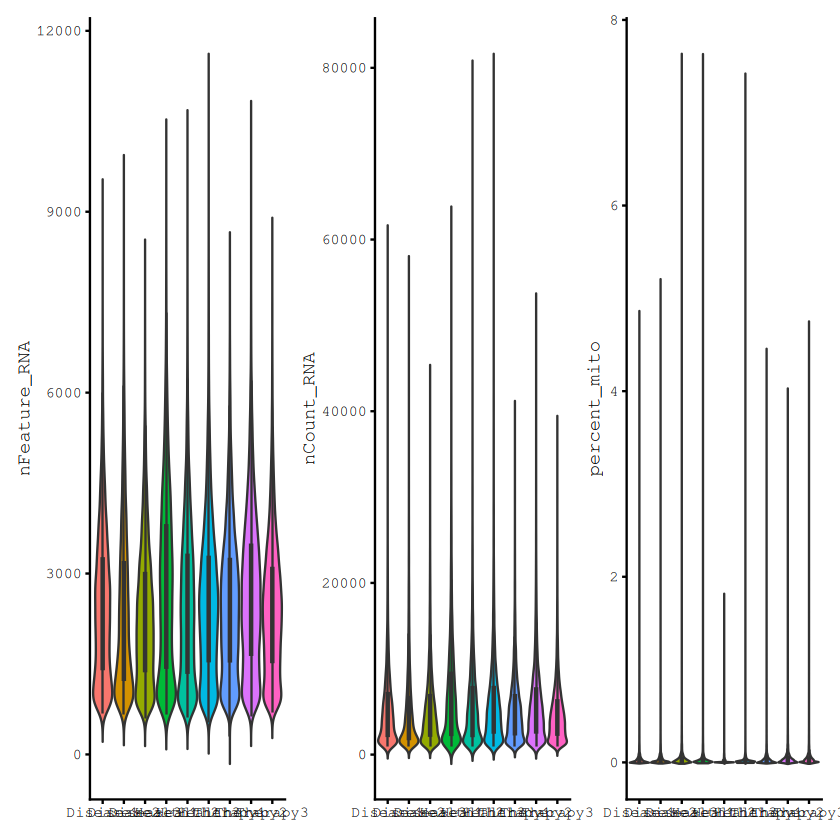

In [ ]:
library(ggplot2)
library(patchwork)

# 1. 
plot_data <- input_sce@meta.data

# 2. 
my_violin <- function(data, feature) {
  ggplot(data, aes_string(x = "orig.ident", y = feature, fill = "orig.ident")) +
    geom_violin(scale = "width", trim = FALSE) +       # 
    geom_boxplot(width = 0.1, fill = "white", outlier.shape = NA) + #
    theme_classic() +                                  # 
    theme(legend.position = "none") +                  # 
    labs(x = NULL, y = feature)                        # 
}

# 3. 分别画三张图
p1 <- my_violin(plot_data, "nFeature_RNA")
p2 <- my_violin(plot_data, "nCount_RNA")
p3 <- my_violin(plot_data, "percent_mito")

# 4. 拼图并强制输出
print(p1 | p2 | p3)

In [7]:
selected_c <- WhichCells(input_sce, expression = nFeature_RNA > 200 & nFeature_RNA < 6000 & percent_mito < 20 & nCount_RNA < 20000)
selected_f <- rownames(input_sce)[Matrix::rowSums(input_sce@assays$RNA@counts > 0 ) > 3]
input_sce.filt <- subset(input_sce, features = selected_f, cells = selected_c)
dim(input_sce) 
dim(input_sce.filt) 

[1]  26841 143828

[1]  26376 141534

In [8]:
selected_mito <- WhichCells(input_sce.filt, expression = percent_mito < 20)
input_sce.filt <- subset(input_sce.filt, cells = selected_mito)

In [9]:
sce = input_sce.filt

In [10]:
sce$sample = sce$orig.ident
unique(sce$sample)

[1] "Disease1" "Disease2" "Disease3" "Health1"  "Health2"  "Health3"  "Therapy1"
[8] "Therapy2" "Therapy3"

In [11]:
sce$group  = 'lalala'
sce$group[grep("Disease", sce$sample)] <- "Disease"
sce$group[grep("Health", sce$sample)] <- "Health"
sce$group[grep("Therapy", sce$sample)] <- "Therapy"
#sce$group[grep("P45WT", sce$sample)] <- "P45WT"

In [12]:
table(sce$group)


Disease  Health Therapy 
  47416   42753   51365 

In [1]:
47416+42753+51365

[1] 141534

In [13]:
sce@meta.data[1:3,]

,orig.ident,nCount_RNA,nFeature_RNA,percent_mito,sample,group
,<chr>,<dbl>,<int>,<dbl>,<chr>,<chr>
Disease1_CELL1_N2,Disease1,4284,2278,0.02334267,Disease1,Disease
Disease1_CELL3_N3,Disease1,13738,4689,0.00000000,Disease1,Disease
Disease1_CELL4_N2,Disease1,7104,3233,0.01407658,Disease1,Disease


In [14]:
qs::qsave(sce,file = '../output/sce.raw.qs')

In [15]:
library(sceasy)
library(reticulate)
library(tidyverse)
use_condaenv('~/miniforge3/envs/danxibao')
loompy <- reticulate::import('loompy')

Loading required package: reticulate



In [16]:
sceasy::convertFormat(sce, from="seurat", to="anndata",
                      outFile='../output/sce.raw.h5ad',main_layer = 'counts',drop_single_values = FALSE)

AnnData object with n_obs × n_vars = 141534 × 26376
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent_mito', 'sample', 'group'
    var: 'name'